
# 04 — N=8 Kuramoto benchmark: relative-polynomial vs candidate libraries

This notebook tests the same planted \(N=8\) temporal Kuramoto system through two different interaction-library choices while keeping the upstream data, temporal segmentation, midpoint reconstruction, uncertainty floor, Step-2 reconstruction, and Step-3 physical hypothesis fixed.

The common pipeline is

\[
x(t)
\longrightarrow
\tau_{1:K-1}
\longrightarrow
\text{common midpoint observations}
\longrightarrow
\begin{cases}
\Psi_{\rm poly} \rightarrow \mathcal B_{\varepsilon}^{\rm poly},\\[1mm]
\Psi_{\rm cand} \rightarrow \mathcal B_{\varepsilon}^{\rm cand},
\end{cases}
\longrightarrow
\text{same }H_{\rm FD}\text{ Step-3 API}.
\]

The two libraries answer different inference questions:

- **relative polynomial**: reconstruct the interaction law in a generic basis
  \[
  z,z^2,\ldots,z^{11},\qquad z=(x_j-x_i)/s;
  \]
- **candidate**: select among predeclared physical mechanisms
  \[
  x_j-x_i,\quad \sin(x_j-x_i),\quad \tanh(x_j-x_i),\quad (x_j-x_i)^3.
  \]

Step 2 returns the same `EdgeSpaceFieldFamily` object type in both cases. Step 3 is called through the same fixed-dynamics physical-compression API; only the internal expression-search strategy and the interpretation of \(\Theta\) differ.

Synthetic truth is used only after inference for validation.


In [1]:

# ============================================================
# Cell 1 — imports and local-code discovery
# ============================================================
from pathlib import Path
from itertools import combinations
import sys
import time
import math
import importlib

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()
CODE_DIR = None

for candidate in (
    HERE,
    HERE / "tides_joint",
    HERE / "tides_new",
    HERE.parent,
    Path("/mnt/data/tides_joint"),
    Path("/mnt/data/tides_new"),
):
    if (candidate / "tides.py").exists():
        CODE_DIR = candidate.resolve()
        break

if CODE_DIR is None:
    raise FileNotFoundError(
        "Could not find tides.py. Put this notebook in the same directory as "
        "the current TIDES source files, or run it from their parent directory."
    )

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import pairwise_local_interaction_library as plib
import mdl_description_length as mdld
import mdl_search as mdls
import step3_physical_compression as step3pc
import tides

# Reload from low-level modules upward so the notebook definitely uses the
# current candidate-branch implementation.
importlib.reload(plib)
importlib.reload(mdld)
importlib.reload(mdls)
importlib.reload(step3pc)
importlib.reload(tides)

print("TIDES loaded from:")
print(tides.__file__)
print("\nStep 3 loaded from:")
print(step3pc.__file__)
print("\nMDL search loaded from:")
print(mdls.__file__)

assert hasattr(
    mdls, "CandidateBranchSummary"
), "This notebook requires the updated candidate-branch mdl_search.py."


TIDES loaded from:
C:\Users\liu.xuanc\Desktop\Code\TIDES-Inference\tides.py

Step 3 loaded from:
C:\Users\liu.xuanc\Desktop\Code\TIDES-Inference\step3_physical_compression.py

MDL search loaded from:
C:\Users\liu.xuanc\Desktop\Code\TIDES-Inference\mdl_search.py


In [2]:

# ============================================================
# Cell 2 — Kuramoto N=8 planted truth
# Same generator as the previous N=8 benchmark.
# ============================================================
SEED = 20260811
N = 8
DT = 5.0e-4
STAGE_DURATION = 0.060
N_STAGES = 6
INTERVALS_PER_STAGE = int(round(STAGE_DURATION / DT))
assert INTERVALS_PER_STAGE == 120

CANDIDATE_EDGES = tuple(combinations(range(1, N + 1), 2))
EDGE_INDEX_1B = {edge: m for m, edge in enumerate(CANDIDATE_EDGES)}
assert len(CANDIDATE_EDGES) == 28

weight_rng = np.random.default_rng(SEED)
EDGE_WEIGHT = {
    edge: int(weight_rng.integers(800, 1201)) / 1000.0
    for edge in CANDIDATE_EDGES
}

SNAPSHOTS = (
    ((1, 3), (2, 5), (2, 8), (3, 5), (3, 8),
     (4, 6), (4, 7), (5, 6), (6, 8), (7, 8)),
    ((1, 3), (1, 5), (2, 3), (2, 8), (3, 5),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 3), (2, 7), (2, 8),
     (3, 8), (4, 6), (4, 7), (5, 6), (7, 8)),
    ((1, 3), (1, 4), (1, 6), (2, 7), (2, 8),
     (3, 8), (4, 5), (4, 6), (5, 6), (7, 8)),
    ((1, 3), (1, 6), (2, 7), (2, 8), (3, 8),
     (4, 5), (5, 6), (5, 7), (6, 7), (7, 8)),
    ((1, 3), (1, 8), (2, 8), (3, 8), (4, 5),
     (4, 8), (5, 6), (5, 7), (6, 7), (7, 8)),
)

X0 = np.array([
    -0.319989, -0.301418, 0.354093, -0.213312,
    -0.026615,  0.067347, 0.282008,  0.157887,
], dtype=float)
X0 -= X0.mean()


def edge_field(x, edge):
    i, j = edge
    i -= 1
    j -= 1
    q = EDGE_WEIGHT[edge] * np.sin(x[j] - x[i])
    out = np.zeros_like(x, dtype=float)
    out[i] += q
    out[j] -= q
    return out


def stage_field(x, stage):
    out = np.zeros(N, dtype=float)
    for edge in SNAPSHOTS[stage]:
        out += edge_field(x, edge)
    return out


def rk4_step(x, dt, stage):
    k1 = stage_field(x, stage)
    k2 = stage_field(x + 0.5 * dt * k1, stage)
    k3 = stage_field(x + 0.5 * dt * k2, stage)
    k4 = stage_field(x + dt * k3, stage)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def is_connected(edge_set):
    adjacency = {i: set() for i in range(1, N + 1)}
    for i, j in edge_set:
        adjacency[i].add(j)
        adjacency[j].add(i)
    seen, stack = {1}, [1]
    while stack:
        u = stack.pop()
        for v in adjacency[u]:
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return len(seen) == N


transition_supports_true = []
for k in range(N_STAGES - 1):
    before = set(SNAPSHOTS[k])
    after = set(SNAPSHOTS[k + 1])
    transition_supports_true.append(tuple(sorted(before ^ after)))

assert all(len(snapshot) == 10 for snapshot in SNAPSHOTS)
assert all(is_connected(snapshot) for snapshot in SNAPSHOTS)
assert all(len(S) == 4 for S in transition_supports_true)

true_change_times = np.arange(1, N_STAGES) * STAGE_DURATION
true_transition_indices = np.rint(true_change_times / DT).astype(int)

print("=" * 90)
print("N=8 Kuramoto benchmark truth")
print("=" * 90)
print("candidate edges M       :", len(CANDIDATE_EDGES))
print("active edges / stage    :", [len(G) for G in SNAPSHOTS])
print("true edge law           : sin(x_neighbor - x_self)")
print("true change times       :", true_change_times)
print("true transition indices :", true_transition_indices)
for k, S in enumerate(transition_supports_true, 1):
    print(f"transition {k}: {S}")


N=8 Kuramoto benchmark truth
candidate edges M       : 28
active edges / stage    : [10, 10, 10, 10, 10, 10]
true edge law           : sin(x_neighbor - x_self)
true change times       : [0.06 0.12 0.18 0.24 0.3 ]
true transition indices : [120 240 360 480 600]
transition 1: ((1, 5), (2, 3), (2, 5), (6, 8))
transition 2: ((1, 5), (1, 6), (2, 7), (3, 5))
transition 3: ((1, 4), (2, 3), (4, 5), (4, 7))
transition 4: ((1, 4), (4, 6), (5, 7), (6, 7))
transition 5: ((1, 6), (1, 8), (2, 7), (4, 8))


Kuramoto trajectory generated
X shape                : (721, 8)
||X(T)-X(0)||          : 4.527580e-01
max |x_i(t)|           : 3.540929e-01
sum_i x_i change       : -3.608225e-16
all finite             : True


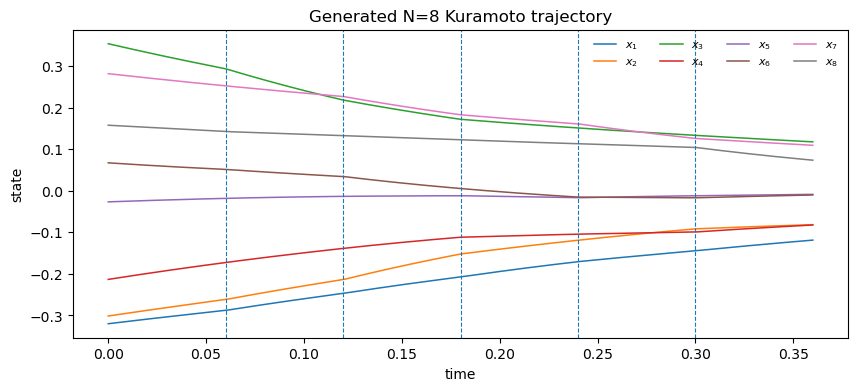

In [3]:

# ============================================================
# Cell 3 — Generate trajectory
# ============================================================
n_total_intervals = N_STAGES * INTERVALS_PER_STAGE
T = np.arange(n_total_intervals + 1, dtype=float) * DT
X = np.empty((n_total_intervals + 1, N), dtype=float)
X[0] = X0

true_stage_of_interval = np.repeat(
    np.arange(N_STAGES, dtype=int), INTERVALS_PER_STAGE
)
for n, stage in enumerate(true_stage_of_interval):
    X[n + 1] = rk4_step(X[n], DT, int(stage))

t = T.copy()

state_displacement = np.linalg.norm(X[-1] - X[0])
max_abs_state = np.max(np.abs(X))
net_sum_change = float(X[-1].sum() - X[0].sum())

print("=" * 90)
print("Kuramoto trajectory generated")
print("=" * 90)
print("X shape                :", X.shape)
print("||X(T)-X(0)||          :", f"{state_displacement:.6e}")
print("max |x_i(t)|           :", f"{max_abs_state:.6e}")
print("sum_i x_i change       :", f"{net_sum_change:.6e}")
print("all finite             :", np.isfinite(X).all())

assert X.shape == (721, 8)
assert np.allclose(np.diff(t), DT)
assert np.isfinite(X).all()
assert abs(net_sum_change) < 1e-10

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(N):
    ax.plot(t, X[:, i], lw=1.1, label=f"$x_{i+1}$")
for tc in true_change_times:
    ax.axvline(tc, ls="--", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("state")
ax.set_title("Generated N=8 Kuramoto trajectory")
ax.legend(ncol=4, fontsize=8, frameon=False)
plt.show()


STEP 1 — blind temporal segmentation
jump median       : 2.052779750772e-03
jump MAD          : 3.333185449132e-04
blind threshold   : 8.719150649037e-03
true indices      : [120 240 360 480 600]
detected indices  : [120 240 360 480 600]
detected times    : [0.06 0.12 0.18 0.24 0.3 ]


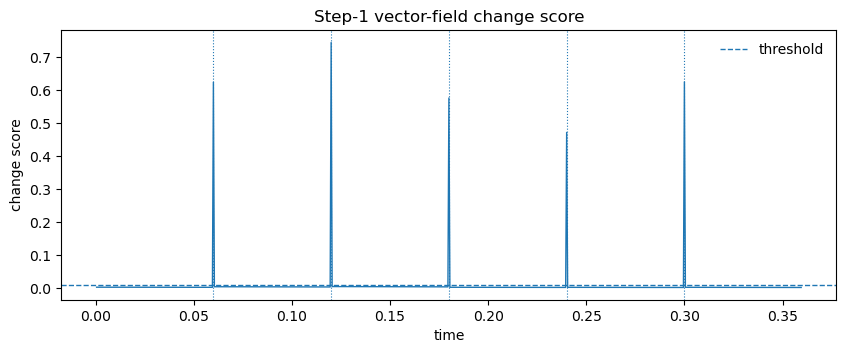

TIDES STEP 1: PASS


In [4]:

# ============================================================
# Cell 4 — Candidate-edge incidence + blind Step 1
# ============================================================
M = len(CANDIDATE_EDGES)
D = np.zeros((N, M), dtype=float)
for m, (i, j) in enumerate(CANDIDATE_EDGES):
    D[i - 1, m] = -1.0
    D[j - 1, m] = +1.0

V_SECANT = np.diff(X, axis=0) / DT
jump = np.linalg.norm(V_SECANT[1:] - V_SECANT[:-1], axis=1)
jump_median = float(np.median(jump))
jump_mad = float(np.median(np.abs(jump - jump_median)))
blind_threshold = jump_median + 20.0 * jump_mad

s1_check = tides.detect_changes(
    X,
    t,
    method="secant",
    threshold=blind_threshold,
    min_separation=1,
)

print("=" * 90)
print("STEP 1 — blind temporal segmentation")
print("=" * 90)
print("jump median       :", f"{jump_median:.12e}")
print("jump MAD          :", f"{jump_mad:.12e}")
print("blind threshold   :", f"{blind_threshold:.12e}")
print("true indices      :", true_transition_indices)
print("detected indices  :", s1_check.transition_indices)
print("detected times    :", s1_check.transition_times)

assert np.array_equal(s1_check.transition_indices, true_transition_indices)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(s1_check.score_times, s1_check.scores, lw=1.0)
ax.axhline(blind_threshold, ls="--", lw=1.0, label="threshold")
for tc in true_change_times:
    ax.axvline(tc, ls=":", lw=0.8)
ax.set_xlabel("time")
ax.set_ylabel("change score")
ax.set_title("Step-1 vector-field change score")
ax.legend(frameon=False)
plt.show()

print("TIDES STEP 1: PASS")



## Common preprocessing

The two library tests must use exactly the same temporal segmentation, midpoint states, reconstructed derivatives, and uncertainty floor. Therefore preprocessing is performed once before the library paths split.


In [5]:

# ============================================================
# Cell 5 — Common midpoint preprocessing and uncertainty floor
# ============================================================
prep = tides.preprocess_trajectory(
    X,
    t,
    s1_check.transition_indices,
    method="four_point_midpoint",
    resolution_audit=True,
    uncertainty_multiplier=20.0,
)

if prep.estimated_uncertainty_floor is None:
    raise RuntimeError("Resolution audit did not return an uncertainty floor.")

EPSILON = float(prep.estimated_uncertainty_floor)

tail = np.array([i - 1 for i, _ in CANDIDATE_EDGES], dtype=int)
head = np.array([j - 1 for _, j in CANDIDATE_EDGES], dtype=int)
d_all_matrix = prep.x_mid[:, head] - prep.x_mid[:, tail]
d_all = d_all_matrix.ravel()

print("=" * 90)
print("COMMON PREPROCESSING")
print("=" * 90)
print("midpoint state shape        :", prep.x_mid.shape)
print("midpoint derivative shape   :", prep.velocity_mid.shape)
print("samples / stage            :", prep.samples_per_stage.tolist())
print("resolution relative max     :", f"{prep.resolution_relative_max:.12e}")
print("uncertainty floor epsilon   :", f"{EPSILON:.12e}")
print("max |phase difference|      :", f"{np.max(np.abs(d_all)):.12e}")
print("RMS phase difference        :", f"{np.sqrt(np.mean(d_all**2)):.12e}")

assert prep.x_mid.shape == (708, 8)
assert np.array_equal(prep.samples_per_stage, np.array([118] * 6))
assert EPSILON > 0.0


COMMON PREPROCESSING
midpoint state shape        : (708, 8)
midpoint derivative shape   : (708, 8)
samples / stage            : [118, 118, 118, 118, 118, 118]
resolution relative max     : 5.191230605399e-13
uncertainty floor epsilon   : 1.038246121080e-11
max |phase difference|      : 6.728386482590e-01
RMS phase difference        : 2.399667607584e-01



## Path A — relative-polynomial library

This is the dynamics-agnostic reconstruction path used in the previous benchmark:

\[
z=\frac{x_j-x_i}{s},
\qquad
\Psi_{\rm poly}=\{z,z^2,\ldots,z^{11}\}.
\]

The planted sine law is not supplied as an atom; its observed-domain representation is reconstructed through polynomial coefficients.


In [6]:

# ============================================================
# Cell 6A — Build and audit the relative-polynomial library
# ============================================================
POLY_DEGREE = 11

POLY_LIBRARY = tides.build_interaction_library(
    prep.x_mid,
    D,
    mode="relative_polynomial",
    degree=POLY_DEGREE,
    check_sampled_swap_equivariance=True,
)

L_POLY = POLY_LIBRARY.n_features
DIFF_SCALE = float(
    POLY_LIBRARY.metadata["atom_metadata"][0]["difference_scale"]
)

THETA_TAYLOR_GAUGE = np.zeros(L_POLY, dtype=float)
for p in range(1, L_POLY + 1):
    if p % 2 == 1:
        k = (p - 1) // 2
        THETA_TAYLOR_GAUGE[p - 1] = (
            ((-1.0) ** k) * DIFF_SCALE ** (p - 1) / math.factorial(p)
        )

z_all = d_all / DIFF_SCALE
f_taylor_phys = DIFF_SCALE * sum(
    THETA_TAYLOR_GAUGE[p - 1] * z_all**p
    for p in range(1, L_POLY + 1)
)
f_true = np.sin(d_all)
taylor_rel_error = (
    np.linalg.norm(f_taylor_phys - f_true) / np.linalg.norm(f_true)
)

print("=" * 90)
print("PATH A — RELATIVE-POLYNOMIAL LIBRARY")
print("=" * 90)
print("requested path                : relative_polynomial")
print("library object mode           :", POLY_LIBRARY.mode)
print("MDL mode                      :", POLY_LIBRARY.metadata.get("mdl_mode"))
print("feature shape                 :", POLY_LIBRARY.endpoint_features.shape)
print("feature labels                :", POLY_LIBRARY.feature_labels)
print("difference scale s            :", f"{DIFF_SCALE:.12e}")
print("Taylor gauge theta            :", np.array2string(THETA_TAYLOR_GAUGE, precision=12))
print("degree-11 Taylor law rel.err  :", f"{taylor_rel_error:.12e}")

assert L_POLY == 11
assert POLY_LIBRARY.endpoint_features.shape == (708, 28, 11, 2)
assert POLY_LIBRARY.metadata.get("mdl_mode") == "polynomial"
assert np.isclose(THETA_TAYLOR_GAUGE[0], 1.0)


PATH A — RELATIVE-POLYNOMIAL LIBRARY
requested path                : relative_polynomial
library object mode           : candidate
MDL mode                      : polynomial
feature shape                 : (708, 28, 11, 2)
feature labels                : ('rel_d^1', 'rel_d^2', 'rel_d^3', 'rel_d^4', 'rel_d^5', 'rel_d^6', 'rel_d^7', 'rel_d^8', 'rel_d^9', 'rel_d^10', 'rel_d^11')
difference scale s            : 6.728386482590e-01
Taylor gauge theta            : [ 1.000000000000e+00  0.000000000000e+00 -7.545197443182e-02
  0.000000000000e+00  1.707900133698e-03  0.000000000000e+00
 -1.840920531713e-05  0.000000000000e+00  1.157509074082e-07
  0.000000000000e+00 -4.763800639758e-10]
degree-11 Taylor law rel.err  : 1.965190378073e-13



## Path B — candidate physical-mechanism library

The candidate path works directly in physical, unnormalised phase differences. The default test dictionary is declared explicitly:

\[
\Psi_{\rm cand}
=
\{
x_j-x_i,\;
\sin(x_j-x_i),\;
\tanh(x_j-x_i),\;
(x_j-x_i)^3
\}.
\]

For the planted Kuramoto generator the exact candidate-space truth is a pure sine atom.


In [7]:

# ============================================================
# Cell 6B — Build and audit the candidate library
# ============================================================
CANDIDATE_ATOMS = plib.common_candidate_atoms(
    "difference",
    harmonics=(1,),
)

CAND_LIBRARY = tides.build_interaction_library(
    prep.x_mid,
    D,
    mode="candidate",
    atoms=CANDIDATE_ATOMS,
    check_sampled_swap_equivariance=True,
)

L_CAND = CAND_LIBRARY.n_features
CAND_LABELS = CAND_LIBRARY.feature_labels
SIN_ATOM = CAND_LABELS.index("sin_difference")

THETA_TRUE_CANDIDATE = np.zeros(L_CAND, dtype=float)
THETA_TRUE_CANDIDATE[SIN_ATOM] = 1.0

sin_feature = CAND_LIBRARY.endpoint_features[:, :, SIN_ATOM, :]
sin_true_tail = np.sin(d_all_matrix)
sin_true_head = -np.sin(d_all_matrix)

sin_tail_rel_error = (
    np.linalg.norm(sin_feature[:, :, 0] - sin_true_tail)
    / np.linalg.norm(sin_true_tail)
)
sin_head_rel_error = (
    np.linalg.norm(sin_feature[:, :, 1] - sin_true_head)
    / np.linalg.norm(sin_true_head)
)
sin_antisymmetry_error = (
    np.linalg.norm(sin_feature[:, :, 0] + sin_feature[:, :, 1])
    / np.linalg.norm(sin_feature[:, :, 0])
)

print("=" * 90)
print("PATH B — CANDIDATE LIBRARY")
print("=" * 90)
print("library mode                  :", CAND_LIBRARY.mode)
print("MDL mode                      :", CAND_LIBRARY.metadata.get("mdl_mode"))
print("feature shape                 :", CAND_LIBRARY.endpoint_features.shape)
print("feature labels                :", CAND_LABELS)
print("ground-truth sine atom index  :", SIN_ATOM)
print("candidate truth theta         :", THETA_TRUE_CANDIDATE)
print("sine tail evaluation rel.err  :", f"{sin_tail_rel_error:.12e}")
print("sine head evaluation rel.err  :", f"{sin_head_rel_error:.12e}")
print("sine antisymmetry rel.err     :", f"{sin_antisymmetry_error:.12e}")

assert L_CAND == 4
assert CAND_LIBRARY.endpoint_features.shape == (708, 28, 4, 2)
assert CAND_LIBRARY.metadata.get("mdl_mode") == "candidate"
assert sin_tail_rel_error < 1e-14
assert sin_head_rel_error < 1e-14
assert sin_antisymmetry_error < 1e-14


PATH B — CANDIDATE LIBRARY
library mode                  : candidate
MDL mode                      : candidate
feature shape                 : (708, 28, 4, 2)
feature labels                : ('linear_difference', 'sin_difference', 'tanh_difference_s1.0', 'cubic_difference')
ground-truth sine atom index  : 1
candidate truth theta         : [0. 1. 0. 0.]
sine tail evaluation rel.err  : 0.000000000000e+00
sine head evaluation rel.err  : 0.000000000000e+00
sine antisymmetry rel.err     : 0.000000000000e+00



## Step 2 — same reconstruction API, two libraries

Both evaluated libraries are passed to exactly the same Step-2 reconstruction routine. The resulting objects have the same `EdgeSpaceFieldFamily` interface; only the library dimension and basis interpretation differ.


In [8]:

# ============================================================
# Cell 7 — Step 2 for both library paths
# ============================================================
STEP2_KWARGS = {
    "design_mode": "dense",
    "solver_method": "dense_lstsq",
}

t0 = time.perf_counter()
POLY_FAMILY, _ = tides.run_tides_from_observations(
    prep.pairwise_target,
    D,
    POLY_LIBRARY,
    prep.stage_of_observation,
    uncertainty_floor=EPSILON,
    run_physical_compression=False,
    step2_kwargs=STEP2_KWARGS,
)
poly_step2_elapsed = time.perf_counter() - t0

t0 = time.perf_counter()
CAND_FAMILY, _ = tides.run_tides_from_observations(
    prep.pairwise_target,
    D,
    CAND_LIBRARY,
    prep.stage_of_observation,
    uncertainty_floor=EPSILON,
    run_physical_compression=False,
    step2_kwargs=STEP2_KWARGS,
)
cand_step2_elapsed = time.perf_counter() - t0


def print_family_audit(name, family, expected_L):
    print("\n" + "=" * 90)
    print(f"STEP 2 — {name}")
    print("=" * 90)
    print("reference B shape         :", family.reference_B_stages.shape)
    print("parameter count           :", family.parameter_count)
    print("rank                      :", family.rank)
    print("nullity                   :", family.nullity)
    print("minimum relative residual :", f"{family.minimum_relative_residual:.12e}")
    print("uncertainty floor         :", f"{family.uncertainty_floor:.12e}")
    print("slack^2                   :", f"{family.slack_squared:.12e}")
    print("stage ranks               :", [g.rank for g in family.stage_geometry])
    print("stage nullities           :", [g.nullity for g in family.stage_geometry])

    assert family.reference_B_stages.shape == (6, 28, expected_L)
    assert family.parameter_count == 6 * 28 * expected_L
    assert family.rank is not None and family.nullity is not None
    assert family.rank + family.nullity == family.parameter_count
    assert family.minimum_relative_residual <= family.uncertainty_floor
    assert not family.is_empty


print_family_audit("RELATIVE POLYNOMIAL", POLY_FAMILY, L_POLY)
print("elapsed / s               :", f"{poly_step2_elapsed:.3f}")

print_family_audit("CANDIDATE", CAND_FAMILY, L_CAND)
print("elapsed / s               :", f"{cand_step2_elapsed:.3f}")

# Explicitly exhibit alternative members of each observational family.
POLY_B_ALT = POLY_FAMILY.sample_feasible(
    rng=np.random.default_rng(20260916),
    null_scale=1.0,
    boundary_fraction=0.85,
)
CAND_B_ALT = CAND_FAMILY.sample_feasible(
    rng=np.random.default_rng(20260917),
    null_scale=1.0,
    boundary_fraction=0.85,
)

assert POLY_FAMILY.is_feasible(POLY_B_ALT)
assert CAND_FAMILY.is_feasible(CAND_B_ALT)

print("\nAlternative-family-member checks")
print(
    "poly  : distance / rho =",
    f"{np.linalg.norm(POLY_B_ALT - POLY_FAMILY.reference_B_stages):.6e}",
    "/",
    f"{POLY_FAMILY.relative_residual(POLY_B_ALT):.6e}",
)
print(
    "cand  : distance / rho =",
    f"{np.linalg.norm(CAND_B_ALT - CAND_FAMILY.reference_B_stages):.6e}",
    "/",
    f"{CAND_FAMILY.relative_residual(CAND_B_ALT):.6e}",
)



STEP 2 — RELATIVE POLYNOMIAL
reference B shape         : (6, 28, 11)
parameter count           : 1848
rank                      : 498
nullity                   : 1350
minimum relative residual : 8.324112315462e-14
uncertainty floor         : 1.038246121080e-11
slack^2                   : 1.488144471624e-19
stage ranks               : [80, 83, 87, 84, 81, 83]
stage nullities           : [228, 225, 221, 224, 227, 225]
elapsed / s               : 0.864

STEP 2 — CANDIDATE
reference B shape         : (6, 28, 4)
parameter count           : 672
rank                      : 312
nullity                   : 360
minimum relative residual : 7.568072549788e-14
uncertainty floor         : 1.038246121080e-11
slack^2                   : 1.488161059876e-19
stage ranks               : [49, 53, 55, 52, 51, 52]
stage nullities           : [63, 59, 57, 60, 61, 60]
elapsed / s               : 0.180

Alternative-family-member checks
poly  : distance / rho = 2.946788e+11 / 8.825591e-12
cand  : distance / rho


## Step 3 — one physical-compression API

Both Step-2 families enter the same fixed-dynamics hypothesis

\[
B^{(r)}=W^{(r)}\Theta^\top.
\]

The same structural coordinates are used in both cases:

\[
W^{(1)},\Delta W^{(1)},\ldots,\Delta W^{(5)}.
\]

The common Step-3 wrapper below deliberately does not specify `initial_atoms`.

- For the polynomial library this triggers the ordinary shared-coefficient search.
- For the candidate library the updated search code first screens each pure candidate law under the maximal structural dictionary, completes every continuously feasible branch, and compares their final MDL values.

The structural-search and precision budgets are otherwise shared.


In [9]:

# ============================================================
# Cell 8 — Common Step-3 wrapper
# ============================================================
STEP3_KWARGS = dict(
    quantizer_bound=8.0,
    search_strategy="alternating_profiled",

    # Stage A — shared-law / branch basin.
    n_basin_hops=10,
    basin_seed=20260916,
    basin_local_max_nfev=50,

    # Stage B — structural screen -> joint refinement.
    max_sweeps=50,
    max_mdl_search_rounds=5,
    structural_joint_candidates=1,
    structural_beyond_boundary=0,
    structural_polish_sweeps=1,

    # Stage C — interaction-expression compression / expansion.
    max_expression_sweeps=8,

    # Joint / precision controls.
    q_min=1,
    q_max=64,
    max_nfev=50,
    final_max_nfev=100,
    max_coordinate_passes=1,

    # Local shortlists. Candidate branches start from one pure atom, so
    # candidate additions/swaps remain enabled.
    top_group_drops=1,
    top_group_adds=1,
    top_group_swaps=1,
    top_atom_drops=1,
    top_atom_adds=1,
    top_atom_swaps=1,
)


def run_step3(name, family):
    print("\n" + "=" * 90)
    print(f"STEP 3 START — {name}")
    print("=" * 90)

    t0 = time.perf_counter()
    result = step3pc.compress_fixed_dynamics(
        family,
        **STEP3_KWARGS,
    )
    elapsed = time.perf_counter() - t0

    print("elapsed / s                 :", f"{elapsed:.3f}")
    print("search strategy             :", result.search_result.search_strategy)
    print("initial structural groups   :", len(result.search_result.initial_state.active_groups))
    print("final structural groups     :", len(result.search_result.best_state.active_groups))
    print("structural accepted moves   :", len(result.search_result.structural_history))
    print("expression accepted moves   :", len(result.search_result.expression_history))
    print("final active atoms          :", result.active_atoms)
    print("continuous residual         :", f"{result.continuous_relative_residual:.12e}")
    print("finite-precision residual   :", f"{result.relative_residual:.12e}")
    print("uncertainty floor           :", f"{result.uncertainty_floor:.12e}")
    print("q upper bound               :", result.q_upper)
    print("initial MDL / bits          :", f"{result.search_result.initial_state.mdl_upper.total_bits:.3f}")
    print("final MDL / bits            :", f"{result.mdl_score.total_bits:.3f}")
    print(
        "anchor -> final theta drift :",
        f"{result.metadata['theta_anchor_to_final_relative_change']:.12e}",
    )

    assert result.feasible
    assert len(result.search_result.initial_state.active_groups) == 168
    assert len(result.search_result.best_state.active_groups) < 168

    return result, elapsed


In [10]:

# ============================================================
# Cell 9A — Run Step 3: relative-polynomial path
# ============================================================
POLY_RESULT, poly_step3_elapsed = run_step3(
    "RELATIVE POLYNOMIAL",
    POLY_FAMILY,
)

print("\nAccepted polynomial path:")
for h in POLY_RESULT.search_result.history:
    print(
        f"  {h.phase:18s} | {h.move.label():18s} | "
        f"{h.old_mdl_upper / np.log(2):9.3f} -> "
        f"{h.new_mdl_upper / np.log(2):9.3f} bits | "
        f"dtheta={h.theta_relative_change if h.theta_relative_change is not None else np.nan:.3e}"
    )



STEP 3 START — RELATIVE POLYNOMIAL
elapsed / s                 : 52.698
search strategy             : alternating_profiled
initial structural groups   : 168
final structural groups     : 30
structural accepted moves   : 2
expression accepted moves   : 6
final active atoms          : (0, 2, 4, 6, 8)
continuous residual         : 2.061332970954e-13
finite-precision residual   : 9.167237434860e-12
uncertainty floor           : 1.038246121080e-11
q upper bound               : 39
initial MDL / bits          : 6988.067
final MDL / bits            : 1473.160
anchor -> final theta drift : 1.696363979090e-09

Accepted polynomial path:
  structural_batch   | drop_batch(62)     |  6988.067 ->  4679.672 bits | dtheta=1.396e-10
  structural_batch   | drop_batch(76)     |  4679.672 ->  1701.320 bits | dtheta=1.344e-11
  expression         | drop_atom(1)       |  1701.320 ->  1665.642 bits | dtheta=3.159e-12
  expression         | drop_atom(3)       |  1665.642 ->  1628.812 bits | dtheta=8.432e-12
 

In [11]:

# ============================================================
# Cell 9B — Run Step 3: candidate path
# ============================================================
CAND_RESULT, cand_step3_elapsed = run_step3(
    "CANDIDATE",
    CAND_FAMILY,
)

print("\nCandidate pure-law branch audit:")
branches = CAND_RESULT.search_result.candidate_branches

if not branches:
    print("  No candidate-branch summary found.")
else:
    for b in branches:
        seed_name = CAND_LABELS[b.seed_atom]
        final_names = tuple(CAND_LABELS[a] for a in b.final_atoms)
        initial_bits = (
            np.nan if b.initial_mdl is None else b.initial_mdl / np.log(2)
        )
        final_bits = (
            np.nan if b.final_mdl is None else b.final_mdl / np.log(2)
        )
        print(
            f"  {seed_name:24s} | "
            f"rho_dense={b.initial_relative_residual:.6e} | "
            f"status={b.status:28s} | "
            f"MDL {initial_bits:9.3f} -> {final_bits:9.3f} bits | "
            f"final atoms={final_names} | "
            f"groups={len(b.final_groups)}"
        )

print("\nAccepted candidate path:")
for h in CAND_RESULT.search_result.history:
    print(
        f"  {h.phase:18s} | {h.move.label():18s} | "
        f"{h.old_mdl_upper / np.log(2):9.3f} -> "
        f"{h.new_mdl_upper / np.log(2):9.3f} bits | "
        f"dtheta={h.theta_relative_change if h.theta_relative_change is not None else np.nan:.3e}"
    )



STEP 3 START — CANDIDATE
elapsed / s                 : 7.583
search strategy             : alternating_profiled
initial structural groups   : 168
final structural groups     : 30
structural accepted moves   : 2
expression accepted moves   : 0
final active atoms          : (1,)
continuous residual         : 8.295569444693e-14
finite-precision residual   : 4.545031630629e-12
uncertainty floor           : 1.038246121080e-11
q upper bound               : 39
initial MDL / bits          : 6595.148
final MDL / bits            : 1308.401
anchor -> final theta drift : 0.000000000000e+00

Candidate pure-law branch audit:
  linear_difference        | rho_dense=2.839467e-03 | status=outside_continuous_floor     | MDL       nan ->       nan bits | final atoms=() | groups=0
  sin_difference           | rho_dense=4.819452e-14 | status=completed                    | MDL  6595.148 ->  1308.401 bits | final atoms=('sin_difference',) | groups=30
  tanh_difference_s1.0     | rho_dense=1.579464e-06 | stat


## Common structural validation

Topology and temporal-change supports have the same physical meaning in both library modes, so support validation is shared.


In [13]:

# ============================================================
# Cell 10 — Common topology-support validation
# ============================================================
TRUE_BASELINE_INDEX = tuple(sorted(EDGE_INDEX_1B[e] for e in SNAPSHOTS[0]))
TRUE_CHANGE_INDEX = tuple(
    tuple(sorted(EDGE_INDEX_1B[e] for e in support))
    for support in transition_supports_true
)


def validate_supports(name, result):
    baseline_recovered = tuple(result.baseline_support.tolist())
    change_recovered = tuple(tuple(s.tolist()) for s in result.change_supports)

    baseline_exact = baseline_recovered == TRUE_BASELINE_INDEX
    changes_exact = tuple(
        inferred == truth
        for inferred, truth in zip(change_recovered, TRUE_CHANGE_INDEX)
    )

    print("\n" + "=" * 90)
    print(f"STRUCTURAL RECOVERY — {name}")
    print("=" * 90)
    print("baseline truth     :", TRUE_BASELINE_INDEX)
    print("baseline recovered :", baseline_recovered)
    print("baseline exact     :", baseline_exact)

    for k, (truth, inferred, ok) in enumerate(
        zip(TRUE_CHANGE_INDEX, change_recovered, changes_exact), 1
    ):
        print(f"\nDelta-W transition {k}")
        print("  truth     :", truth)
        print("  recovered :", inferred)
        print("  exact     :", ok)

    assert baseline_exact
    assert all(changes_exact)
    assert len(result.baseline_support) == 10
    assert [len(s) for s in result.change_supports] == [4, 4, 4, 4, 4]

    return baseline_exact, changes_exact


POLY_BASELINE_EXACT, POLY_CHANGES_EXACT = validate_supports(
    "RELATIVE POLYNOMIAL",
    POLY_RESULT,
)
CAND_BASELINE_EXACT, CAND_CHANGES_EXACT = validate_supports(
    "CANDIDATE",
    CAND_RESULT,
)

print("\nBOTH LIBRARY PATHS RECOVER THE PLANTED SUPPORTS EXACTLY")



STRUCTURAL RECOVERY — RELATIVE POLYNOMIAL
baseline truth     : (1, 9, 12, 14, 17, 19, 20, 22, 26, 27)
baseline recovered : (1, 9, 12, 14, 17, 19, 20, 22, 26, 27)
baseline exact     : True

Delta-W transition 1
  truth     : (3, 7, 9, 26)
  recovered : (3, 7, 9, 26)
  exact     : True

Delta-W transition 2
  truth     : (3, 4, 11, 14)
  recovered : (3, 4, 11, 14)
  exact     : True

Delta-W transition 3
  truth     : (2, 7, 18, 20)
  recovered : (2, 7, 18, 20)
  exact     : True

Delta-W transition 4
  truth     : (2, 19, 23, 25)
  recovered : (2, 19, 23, 25)
  exact     : True

Delta-W transition 5
  truth     : (4, 6, 11, 21)
  recovered : (4, 6, 11, 21)
  exact     : True

STRUCTURAL RECOVERY — CANDIDATE
baseline truth     : (1, 9, 12, 14, 17, 19, 20, 22, 26, 27)
baseline recovered : (1, 9, 12, 14, 17, 19, 20, 22, 26, 27)
baseline exact     : True

Delta-W transition 1
  truth     : (3, 7, 9, 26)
  recovered : (3, 7, 9, 26)
  exact     : True

Delta-W transition 2
  truth     : (3, 


## Path-specific dynamics validation

The topology is common, but the \(\Theta\) coordinates are not.

For the relative-polynomial path, the gauge \(\theta_1=1\) implies planted active structural amplitudes

\[
W^{\rm poly}_{m}=sA_m.
\]

For the pure sine candidate path,

\[
\Theta_{\rm cand}=e_{\sin},
\]

so the structural amplitude is directly the physical Kuramoto edge weight,

\[
W^{\rm cand}_{m}=A_m.
\]


POLYNOMIAL DYNAMICS / AMPLITUDE AUDIT
theta anchor vs Taylor rel.err : 1.296085414480e-10
theta final vs selected ref    : 1.648311907644e-09
anchor -> final theta drift    : 1.696363979090e-09
continuous W rel.err           : 3.120196899617e-12
continuous Delta-W rel.err     : 2.987414539824e-12
max inactive continuous |W|    : 3.569256001867e-12
active polynomial powers       : (1, 3, 5, 7, 9)


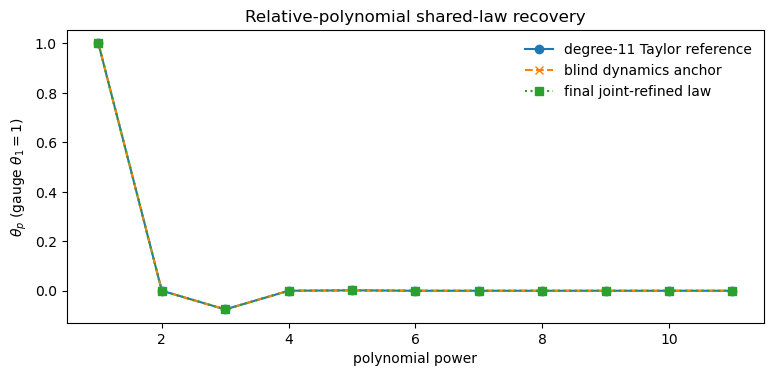

In [14]:

# ============================================================
# Cell 11A — Polynomial dynamics + amplitude audit
# ============================================================
poly_theta_anchor = np.asarray(
    POLY_RESULT.search_result.theta_anchor,
    dtype=float,
)
poly_theta_final = np.asarray(
    POLY_RESULT.continuous_theta,
    dtype=float,
)

poly_theta_anchor_rel = (
    np.linalg.norm(poly_theta_anchor - THETA_TAYLOR_GAUGE)
    / np.linalg.norm(THETA_TAYLOR_GAUGE)
)

poly_theta_reference_selected = THETA_TAYLOR_GAUGE.copy()
for a in range(L_POLY):
    if a not in POLY_RESULT.active_atoms:
        poly_theta_reference_selected[a] = 0.0

poly_theta_final_rel = (
    np.linalg.norm(poly_theta_final - poly_theta_reference_selected)
    / np.linalg.norm(poly_theta_reference_selected)
)

W_TRUE_POLY = np.zeros((N_STAGES, M), dtype=float)
for r, snapshot in enumerate(SNAPSHOTS):
    for edge in snapshot:
        W_TRUE_POLY[r, EDGE_INDEX_1B[edge]] = DIFF_SCALE * EDGE_WEIGHT[edge]

dW_TRUE_POLY = np.diff(W_TRUE_POLY, axis=0)
active_W_poly = W_TRUE_POLY != 0.0
active_dW_poly = dW_TRUE_POLY != 0.0

poly_W_cont_rel = (
    np.linalg.norm(
        (POLY_RESULT.continuous_W_stages - W_TRUE_POLY)[active_W_poly]
    )
    / np.linalg.norm(W_TRUE_POLY[active_W_poly])
)
poly_dW_cont_rel = (
    np.linalg.norm(
        (
            np.diff(POLY_RESULT.continuous_W_stages, axis=0)
            - dW_TRUE_POLY
        )[active_dW_poly]
    )
    / np.linalg.norm(dW_TRUE_POLY[active_dW_poly])
)
poly_inactive_W_max = float(
    np.max(np.abs(POLY_RESULT.continuous_W_stages[~active_W_poly]))
)

poly_active_powers = tuple(a + 1 for a in POLY_RESULT.active_atoms)

print("=" * 90)
print("POLYNOMIAL DYNAMICS / AMPLITUDE AUDIT")
print("=" * 90)
print("theta anchor vs Taylor rel.err :", f"{poly_theta_anchor_rel:.12e}")
print("theta final vs selected ref    :", f"{poly_theta_final_rel:.12e}")
print("anchor -> final theta drift    :", f"{POLY_RESULT.metadata['theta_anchor_to_final_relative_change']:.12e}")
print("continuous W rel.err           :", f"{poly_W_cont_rel:.12e}")
print("continuous Delta-W rel.err     :", f"{poly_dW_cont_rel:.12e}")
print("max inactive continuous |W|    :", f"{poly_inactive_W_max:.12e}")
print("active polynomial powers       :", poly_active_powers)

assert poly_theta_anchor_rel < 1e-6
assert poly_theta_final_rel < 1e-6
assert poly_W_cont_rel < 1e-8
assert poly_dW_cont_rel < 1e-8
assert poly_inactive_W_max < 1e-8
assert all(p % 2 == 1 for p in poly_active_powers)

fig, ax = plt.subplots(figsize=(9, 3.8))
powers = np.arange(1, L_POLY + 1)
ax.plot(powers, THETA_TAYLOR_GAUGE, "o-", label="degree-11 Taylor reference")
ax.plot(powers, poly_theta_anchor, "x--", label="blind dynamics anchor")
ax.plot(powers, poly_theta_final, "s:", label="final joint-refined law")
ax.set_xlabel("polynomial power")
ax.set_ylabel(r"$\theta_p$ (gauge $\theta_1=1$)")
ax.set_title("Relative-polynomial shared-law recovery")
ax.legend(frameon=False)
plt.show()


CANDIDATE DYNAMICS / AMPLITUDE AUDIT
candidate labels                : ('linear_difference', 'sin_difference', 'tanh_difference_s1.0', 'cubic_difference')
final active candidate names    : ('sin_difference',)
final theta                     : [0. 1. 0. 0.]
theta vs pure-sine truth rel.err: 0.000000000000e+00
anchor -> final theta drift      : 0.000000000000e+00
continuous W rel.err             : 3.940852490569e-13
continuous Delta-W rel.err       : 4.702554999506e-13
max inactive continuous |W|      : 1.106892355551e-12


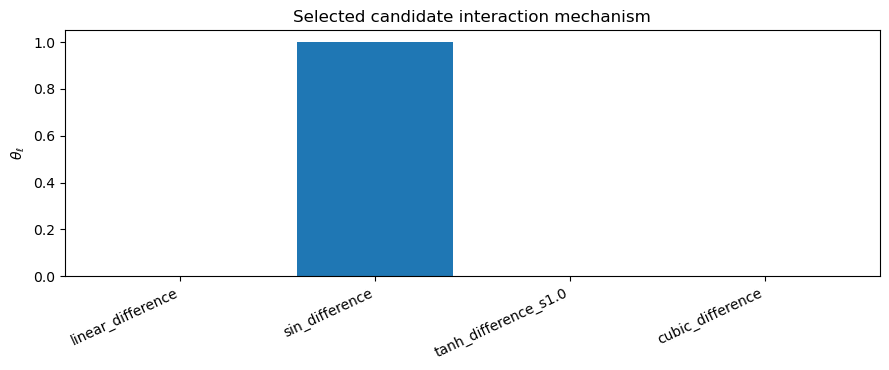

In [15]:

# ============================================================
# Cell 11B — Candidate mechanism + amplitude audit
# ============================================================
cand_theta_anchor = np.asarray(
    CAND_RESULT.search_result.theta_anchor,
    dtype=float,
)
cand_theta_final = np.asarray(
    CAND_RESULT.continuous_theta,
    dtype=float,
)

cand_active_names = tuple(
    CAND_LABELS[a] for a in CAND_RESULT.active_atoms
)

cand_theta_final_rel = (
    np.linalg.norm(cand_theta_final - THETA_TRUE_CANDIDATE)
    / np.linalg.norm(THETA_TRUE_CANDIDATE)
)

W_TRUE_CAND = np.zeros((N_STAGES, M), dtype=float)
for r, snapshot in enumerate(SNAPSHOTS):
    for edge in snapshot:
        W_TRUE_CAND[r, EDGE_INDEX_1B[edge]] = EDGE_WEIGHT[edge]

dW_TRUE_CAND = np.diff(W_TRUE_CAND, axis=0)
active_W_cand = W_TRUE_CAND != 0.0
active_dW_cand = dW_TRUE_CAND != 0.0

cand_W_cont_rel = (
    np.linalg.norm(
        (CAND_RESULT.continuous_W_stages - W_TRUE_CAND)[active_W_cand]
    )
    / np.linalg.norm(W_TRUE_CAND[active_W_cand])
)
cand_dW_cont_rel = (
    np.linalg.norm(
        (
            np.diff(CAND_RESULT.continuous_W_stages, axis=0)
            - dW_TRUE_CAND
        )[active_dW_cand]
    )
    / np.linalg.norm(dW_TRUE_CAND[active_dW_cand])
)
cand_inactive_W_max = float(
    np.max(np.abs(CAND_RESULT.continuous_W_stages[~active_W_cand]))
)

print("=" * 90)
print("CANDIDATE DYNAMICS / AMPLITUDE AUDIT")
print("=" * 90)
print("candidate labels                :", CAND_LABELS)
print("final active candidate names    :", cand_active_names)
print("final theta                     :", np.array2string(cand_theta_final, precision=12))
print("theta vs pure-sine truth rel.err:", f"{cand_theta_final_rel:.12e}")
print("anchor -> final theta drift      :", f"{CAND_RESULT.metadata['theta_anchor_to_final_relative_change']:.12e}")
print("continuous W rel.err             :", f"{cand_W_cont_rel:.12e}")
print("continuous Delta-W rel.err       :", f"{cand_dW_cont_rel:.12e}")
print("max inactive continuous |W|      :", f"{cand_inactive_W_max:.12e}")

# This benchmark contains the exact sine mechanism as one candidate atom.
assert CAND_RESULT.active_atoms == (SIN_ATOM,)
assert cand_active_names == ("sin_difference",)
assert cand_theta_final_rel < 1e-10
assert cand_W_cont_rel < 1e-8
assert cand_dW_cont_rel < 1e-8
assert cand_inactive_W_max < 1e-8

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(L_CAND)
ax.bar(x, cand_theta_final)
ax.set_xticks(x)
ax.set_xticklabels(CAND_LABELS, rotation=25, ha="right")
ax.set_ylabel(r"$\theta_\ell$")
ax.set_title("Selected candidate interaction mechanism")
plt.tight_layout()
plt.show()



COMPRESSION PATH — RELATIVE POLYNOMIAL
00 | initial              |   6988.067 bits
01 | drop_batch(62)       |   4679.672 bits
02 | drop_batch(76)       |   1701.320 bits
03 | drop_atom(1)         |   1665.642 bits
04 | drop_atom(3)         |   1628.812 bits
05 | drop_atom(5)         |   1591.227 bits
06 | drop_atom(7)         |   1553.034 bits
07 | drop_atom(9)         |   1514.298 bits
08 | drop_atom(10)        |   1473.160 bits


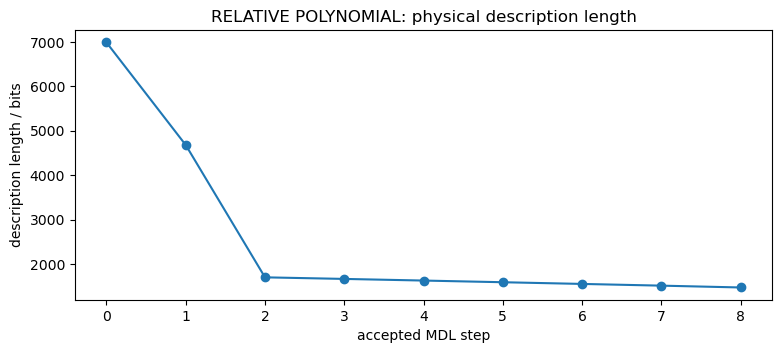


COMPRESSION PATH — CANDIDATE
00 | initial              |   6595.148 bits
01 | drop_batch(120)      |   2035.677 bits
02 | drop_batch(18)       |   1308.401 bits


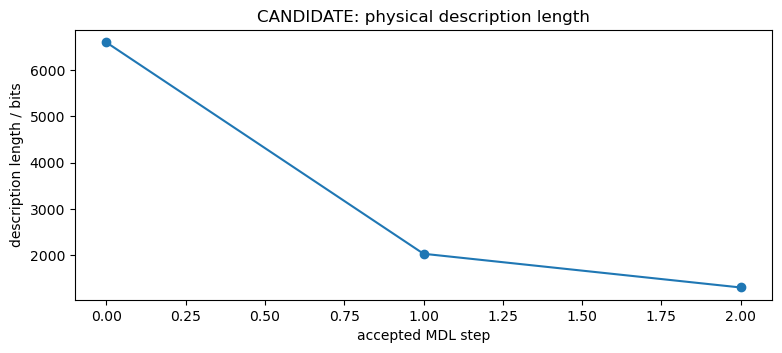

In [16]:

# ============================================================
# Cell 12 — Compression paths
# ============================================================
def plot_mdl_path(name, result):
    mdl_bits = [result.search_result.initial_state.mdl_upper.total_bits]
    labels = ["initial"]

    for h in result.search_result.history:
        mdl_bits.append(h.new_mdl_upper / np.log(2))
        labels.append(h.move.label())

    print("\n" + "=" * 90)
    print(f"COMPRESSION PATH — {name}")
    print("=" * 90)
    for i, (label, bits) in enumerate(zip(labels, mdl_bits)):
        print(f"{i:02d} | {label:20s} | {bits:10.3f} bits")

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(np.arange(len(mdl_bits)), mdl_bits, "o-")
    ax.set_xlabel("accepted MDL step")
    ax.set_ylabel("description length / bits")
    ax.set_title(f"{name}: physical description length")
    plt.show()


plot_mdl_path("RELATIVE POLYNOMIAL", POLY_RESULT)
plot_mdl_path("CANDIDATE", CAND_RESULT)



## Final comparison

The two total MDL values are conditional on different supplied libraries, so they are reported side by side for diagnostics but are **not** interpreted as a library-selection criterion. A formal MDL comparison between library classes would require coding the library choice itself.

The meaningful cross-path checks here are:

- same detected temporal segmentation;
- same preprocessing and uncertainty floor;
- both Step-2 families feasible;
- exact recovery of the same planted topology and temporal changes;
- polynomial path reconstructs the sine law in its generic basis;
- candidate path selects the exact sine mechanism.


In [17]:

# ============================================================
# Cell 13 — Final dual-library benchmark summary
# ============================================================
print("=" * 110)
print("04 — N=8 KURAMOTO / DUAL-LIBRARY TIDES SUMMARY")
print("=" * 110)

print("common Step 1 exact transitions        :", np.array_equal(s1_check.transition_indices, true_transition_indices))
print("common midpoint observations           :", prep.n_observations)
print("common uncertainty floor               :", f"{EPSILON:.6e}")

print("\nRELATIVE POLYNOMIAL")
print("  library size                         :", L_POLY)
print("  Step-2 B shape                       :", POLY_FAMILY.reference_B_stages.shape)
print("  Step-2 rank / nullity                :", POLY_FAMILY.rank, "/", POLY_FAMILY.nullity)
print("  Step-2 minimum residual              :", f"{POLY_FAMILY.minimum_relative_residual:.6e}")
print("  Step-2 elapsed / s                   :", f"{poly_step2_elapsed:.3f}")
print("  Step-3 elapsed / s                   :", f"{poly_step3_elapsed:.3f}")
print("  structural groups                    :", f"{len(POLY_RESULT.search_result.initial_state.active_groups)} -> {len(POLY_RESULT.search_result.best_state.active_groups)}")
print("  baseline support exact               :", POLY_BASELINE_EXACT)
print("  all Delta-W supports exact           :", all(POLY_CHANGES_EXACT))
print("  shared-law anchor/Taylor rel.err     :", f"{poly_theta_anchor_rel:.6e}")
print("  continuous W rel.err                 :", f"{poly_W_cont_rel:.6e}")
print("  continuous Delta-W rel.err           :", f"{poly_dW_cont_rel:.6e}")
print("  final active polynomial powers       :", poly_active_powers)
print("  final residual                       :", f"{POLY_RESULT.relative_residual:.6e}")
print("  conditional MDL bits                 :", f"{POLY_RESULT.search_result.initial_state.mdl_upper.total_bits:.3f} -> {POLY_RESULT.mdl_score.total_bits:.3f}")

print("\nCANDIDATE")
print("  library size                         :", L_CAND)
print("  candidate labels                     :", CAND_LABELS)
print("  Step-2 B shape                       :", CAND_FAMILY.reference_B_stages.shape)
print("  Step-2 rank / nullity                :", CAND_FAMILY.rank, "/", CAND_FAMILY.nullity)
print("  Step-2 minimum residual              :", f"{CAND_FAMILY.minimum_relative_residual:.6e}")
print("  Step-2 elapsed / s                   :", f"{cand_step2_elapsed:.3f}")
print("  Step-3 elapsed / s                   :", f"{cand_step3_elapsed:.3f}")
print("  structural groups                    :", f"{len(CAND_RESULT.search_result.initial_state.active_groups)} -> {len(CAND_RESULT.search_result.best_state.active_groups)}")
print("  baseline support exact               :", CAND_BASELINE_EXACT)
print("  all Delta-W supports exact           :", all(CAND_CHANGES_EXACT))
print("  selected mechanism                   :", cand_active_names)
print("  continuous W rel.err                 :", f"{cand_W_cont_rel:.6e}")
print("  continuous Delta-W rel.err           :", f"{cand_dW_cont_rel:.6e}")
print("  final residual                       :", f"{CAND_RESULT.relative_residual:.6e}")
print("  conditional MDL bits                 :", f"{CAND_RESULT.search_result.initial_state.mdl_upper.total_bits:.3f} -> {CAND_RESULT.mdl_score.total_bits:.3f}")

print("=" * 110)

assert POLY_BASELINE_EXACT and all(POLY_CHANGES_EXACT)
assert CAND_BASELINE_EXACT and all(CAND_CHANGES_EXACT)
assert POLY_RESULT.feasible and CAND_RESULT.feasible
assert poly_W_cont_rel < 1e-8
assert poly_dW_cont_rel < 1e-8
assert cand_W_cont_rel < 1e-8
assert cand_dW_cont_rel < 1e-8
assert poly_theta_anchor_rel < 1e-6
assert CAND_RESULT.active_atoms == (SIN_ATOM,)

print("DUAL-LIBRARY N=8 BENCHMARK: PASS")


04 — N=8 KURAMOTO / DUAL-LIBRARY TIDES SUMMARY
common Step 1 exact transitions        : True
common midpoint observations           : 708
common uncertainty floor               : 1.038246e-11

RELATIVE POLYNOMIAL
  library size                         : 11
  Step-2 B shape                       : (6, 28, 11)
  Step-2 rank / nullity                : 498 / 1350
  Step-2 minimum residual              : 8.324112e-14
  Step-2 elapsed / s                   : 0.864
  Step-3 elapsed / s                   : 52.698
  structural groups                    : 168 -> 30
  baseline support exact               : True
  all Delta-W supports exact           : True
  shared-law anchor/Taylor rel.err     : 1.296085e-10
  continuous W rel.err                 : 3.120197e-12
  continuous Delta-W rel.err           : 2.987415e-12
  final active polynomial powers       : (1, 3, 5, 7, 9)
  final residual                       : 9.167237e-12
  conditional MDL bits                 : 6988.067 -> 1473.160

CANDIDATE
